# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import cell_types, datasets_e, datasets_a, datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, palette_genders, mapping_minor_2_major

from ciim.src.tf_activity.helper import adata_lambda, retrieve_net, calculate_tf_activity, compute_trend, retrieve_sig_stats, retrieve_valid_stats

from ciim.src.tf_activity.plots import plot_net_nx

from ciim.src.utils.plots import dotplot
# from ciim.src.tf_activity.helper import retreive_stats

task_grn_inference_dir = '../../task_grn_inference'


def filter_for_consistent_trends(df):
    consistent_groups = (
        df.groupby(['cell_type', 'tf'])['slope']
        .apply(lambda x: np.sign(x).nunique() == 1)
    )
    valid_tuples = consistent_groups[consistent_groups].index
    filtered_df = df.set_index(['cell_type', 'tf']).loc[valid_tuples].reset_index()
    return filtered_df


In [2]:
# - tf list 
# skeleton = pd.read_csv(f'{task_grn_inference_dir}/resources/grn_benchmark/prior//skeleton.csv')
# consensus_nets_dict = get_consensus_network(cell_types, datasets)

# Some funcs or unknown sections

In [3]:
def compile_data(cell_type, target_tfs, target_filter_criteria='in_degree_c'):
    stats_tf = stats_valid[(stats_valid['cell_type']==cell_type) & (stats_valid['tf'].isin(target_tfs))]
    stats_targets = stats_targets_all[stats_targets_all['cell_type']==cell_type]
    net = consensus_nets_dict[cell_type]
    print('Put the data together ...')
    data_all = obj.wrapper_retreive_stats(stats_tf, stats_targets, net, filter_criteria=target_filter_criteria,
                n_top_targets=20)
    return data_all
if False:
    from ciim.src.tf_activity.plots import DotPlotTFtarget

    obj = DotPlotTFtarget(tf_all, skeleton)
    obj.plot_legend()
    data = compile_data(cell_type, sig_tfs_ts_sorted, target_filter_criteria='meta_p_adj_target')
    obj.plot_dotplot(data, 
                    figsize=(6, 5), 
                    height_ratios=(4, .3), 
                    width_ratios=[0.2, 4], 
                    ax_main_margin=(0.04, .1),
                    title=f"Common TFs to T cells: {cell_type}")
    # - store the net
    net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
    net_dicts[cell_type] = net
def get_known_gene_names():
    import pandas as pd
    gtf_cols = [
        'seqname', 'source', 'feature', 'start', 'end',
        'score', 'strand', 'frame', 'attribute'
    ]

    gtf_path = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/supp_data/gencode.v47.annotation.gtf.gz'

    gtf_df = pd.read_csv(
        gtf_path,
        sep='\t',
        compression='gzip',
        comment='#',
        header=None,
        names=gtf_cols,
        engine='python'
    )
    import re

    # Define known chromosomes (as strings)
    known_chromosomes = [f'chr{i}' for i in range(1, 21)] + ['X', 'Y']

    # Filter rows where feature is 'gene' and on a known chromosome
    genes_df = df_only_genes[
        (gtf_df['feature'] == 'gene') &
        (gtf_df['seqname'].isin(known_chromosomes))
    ].copy()

    # Function to extract gene_name from the attribute column
    def extract_gene_name(attr_str):
        match = re.search(r'gene_name "([^"]+)"', attr_str)
        return match.group(1) if match else None

    # Apply the function
    genes_df['gene_name'] = genes_df['attribute'].apply(extract_gene_name)

    # Drop NA (just in case) and get unique gene names
    gene_names = genes_df['gene_name'].dropna().unique().tolist()
    np.savetxt(
        '/vol/projects/jnourisa/prior/gene_names.txt',
        gene_names,
        fmt='%s'
    )


## Compare nets

In [111]:
# from ciim.src.tf_activity.plots import compare_nets_interaction
if True:
    net_store = []
    for cell_type in cell_types:
        for dataset in datasets_all:
            net = retrieve_net(dataset, cell_type)
            net['edge'] = net['source'] + '_' + net['target']
            net['cell_type'] = cell_type
            net['dataset'] = dataset
            print(f'net: {cell_type} {dataset} ', net.shape)
            net_store.append(net)
    nets_all = pd.concat(net_store)

net: CD4T data1  (3695, 11)
net: CD4T data7_allTPs_jalil  (10233, 11)
net: CD4T data12  (12399, 11)
net: CD4T SLE_European  (1503, 10)
net: CD4T data13_Korean  (14878, 10)
net: CD4T data13_Japanese  (11619, 10)
net: CD4T SLE_Asian  (1783, 10)
net: CD8T data1  (7529, 11)
net: CD8T data7_allTPs_jalil  (28061, 11)
net: CD8T data12  (24551, 11)
net: CD8T SLE_European  (3605, 10)
net: CD8T data13_Korean  (67867, 10)
net: CD8T data13_Japanese  (48566, 10)
net: CD8T SLE_Asian  (3130, 10)
net: NK data1  (1352, 11)
net: NK data7_allTPs_jalil  (6739, 11)
net: NK data12  (3251, 11)
net: NK SLE_European  (669, 10)
net: NK data13_Korean  (8661, 10)
net: NK data13_Japanese  (5023, 10)
net: NK SLE_Asian  (931, 10)
net: B data1  (71655, 11)
net: B data7_allTPs_jalil  (18866, 11)
net: B data12  (13403, 11)
net: B SLE_European  (1031, 10)
net: B data13_Korean  (26700, 10)
net: B data13_Japanese  (12631, 10)
net: B SLE_Asian  (1404, 10)
net: MONO data1  (47923, 11)
net: MONO data7_allTPs_jalil  (62153, 1

        SLE_Asian  SLE_European  data1  data12  data13_Japanese  \
SPI1        False         False  False    True            False   
ZNF207       True          True  False    True             True   
MBNL2       False         False  False    True             True   
ZNF263      False         False  False   False            False   
TSHZ2        True          True   True    True             True   
...           ...           ...    ...     ...              ...   
GABPA       False         False  False   False            False   
ZNF451      False         False  False   False             True   
IKZF5       False         False  False   False            False   
ZNF430      False         False  False    True            False   
ADNP        False         False  False   False            False   

        data13_Korean  data7_allTPs_jalil  
SPI1            False               False  
ZNF207           True                True  
MBNL2            True                True  
ZNF263          Fal

IndexError: index -1 is out of bounds for axis 0 with size 0

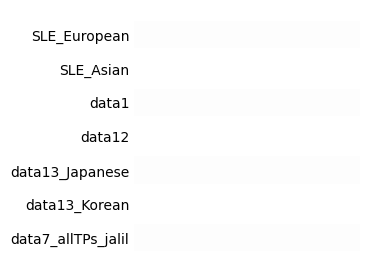

In [ ]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
if True:
    # for source
    to_show='source'

    if to_show=='source':
        min_subset_size=100
        min_degree=1
    if to_show=='target':
        min_subset_size=10
        min_degree=2
    if to_show=='edge':
        min_subset_size=100
        min_degree=2


    for cell_type in cell_types:
        nets = nets_all[nets_all['cell_type']==cell_type]
        # edges
        df_dict = nets.groupby(['dataset'])[to_show].apply(list).to_dict()

        interaction_df = create_interaction_df(df_dict)
        # print(interaction_df)
        # interaction_df.columns = interaction_df.columns.map(surrogate_names)
        aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_datasets_pretty)
        plt.title(cell_type)

# Overall view

## Heatmap of sig TFs across cell types and cohorts

In [32]:
# - read all stats (with and without significance) and add is_significant to mark the significant ones
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')

# - add sig signs for e
stats_e = retrieve_sig_stats(type, race='european')
tuple_index = stats_e.set_index(['cell_type', 'tf', 'dataset']).index
stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all.reset_index(inplace=True)

# - add sig signs for a
stats_a = retrieve_sig_stats(type, race='asian')
tuple_index = stats_a.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf'])
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all.reset_index(inplace=True)



stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)


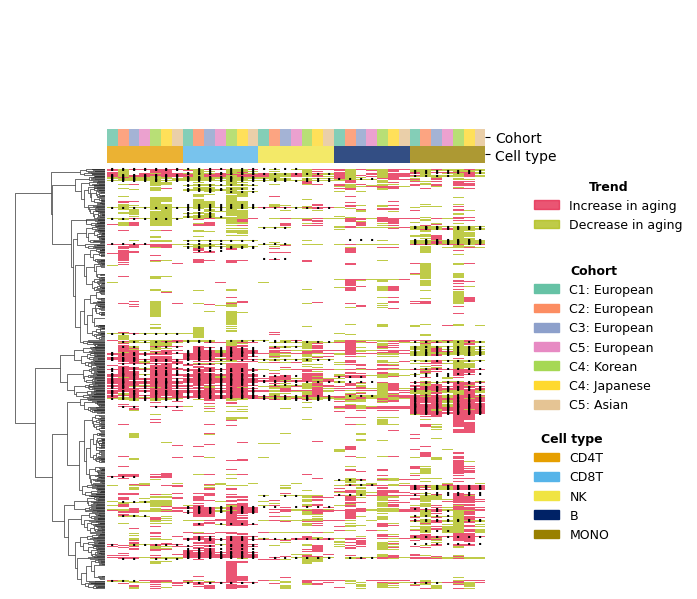

In [33]:
from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor_col2=(1.1, .8),
                    figsize=(6, 8),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Cohort'}, **surrogate_names})
# plt.savefig(f'../output/tf_activation/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

## Intersection of races

{'SOX4', 'DRAP1', 'EEA1', 'ZNF831', 'ZFY', 'NME2', 'CREB3L2', 'MYBL1', 'FOXN3', 'IKZF2', 'KLF10', 'FOXP3', 'ELF1', 'IKZF3', 'BACH2', 'ARHGAP35', 'RARA'}
{'ZSCAN18', 'STAT1', 'IKZF2', 'PLAG1', 'SMAD3', 'ARNTL', 'MSC', 'ZNF581', 'SOX4', 'KLF7', 'SREBF1', 'MTERF4', 'TFEB', 'ZNF439', 'GFI1', 'JAZF1', 'E2F3', 'ELK3', 'ZNF831', 'ZNF600', 'HMGN3', 'KLF10', 'CC2D1A', 'NFKB2', 'TGIF1', 'NME2', 'CREB3L2', 'TFAP4', 'SETBP1', 'ELF1', 'ZNF814', 'ZNF677'}
{'BATF', 'CEBPB', 'BNC2', 'LEF1', 'IRF8', 'NME2', 'TCF4', 'AKNA', 'ATF4', 'FOS', 'BAZ2B'}
{'SOX4', 'GTF3A', 'SP140', 'GTF2IRD2B', 'SP100', 'HIF1A', 'EBF1', 'CXXC5', 'IKZF3'}
{'ZNF428', 'CEBPB', 'IRF7', 'CEBPA', 'BHLHE40', 'GTF2I', 'NFKB2', 'ZNF207', 'TCF4', 'FOXN3', 'ETS2', 'KMT2A', 'ARID5B', 'REPIN1', 'NR4A2'}


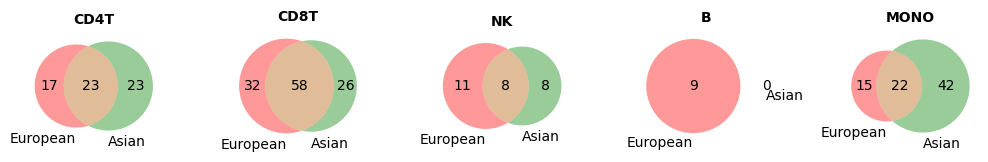

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Collect stats as sets of significant TFs for each analysis and cell type
stats_e = retrieve_sig_stats(type, race='european')
stats_a = retrieve_sig_stats(type, race='asian')


fig, axes = plt.subplots(1, len(cell_types), figsize=(2 * len(cell_types), 2))

if len(cell_types) == 1:
    axes = [axes]

for ax, cell_type in zip(axes, cell_types):

    set_e = set(stats_e[stats_e['cell_type'] == cell_type]['tf'].unique())
    set_a = set(stats_a[stats_a['cell_type'] == cell_type]['tf'].unique())

    print(set_e-set_a)

    v = venn2([set_e, set_a], set_labels=('European', 'Asian'), ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(10)
    for text in v.subset_labels:
        if text: text.set_fontsize(10)
    ax.set_title(cell_type, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Cell type specific plots: explicit dataset stats

In [35]:
from ciim.src.tf_activity.helper import retrieve_sig_stats, retrieve_valid_stats
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')

def subset_func(df1, df2, mode_f=np.intersect1d):
    df_store = []
    for cell_type in df1['cell_type'].unique():
        # - subset
        df1_sub = df1[df1['cell_type'] == cell_type]
        df2_sub = df2[df2['cell_type'] == cell_type]
        # - subset
        tfs = mode_f(df1_sub['tf'].unique(), df2_sub['tf'].unique())
        # - subset
        df1_sub = df1_sub[df1_sub['tf'].isin(tfs)]
        df_store.append(df1_sub)
    df1 = pd.concat(df_store)
    return df1

if False:
    stats_sig_1 = retrieve_sig_stats(type, race='european') 
    stats_sig_2 = retrieve_sig_stats(type, race='asian')
    stats_sig = subset_func(stats_sig_1, stats_sig_2, mode_f=np.intersect1d)
else:
    stats_sig = retrieve_sig_stats(type, race='european', filter_inconsistent=False)

tupled_index = stats_sig.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tupled_index].reset_index().drop_duplicates(subset=['cell_type', 'tf', 'dataset'])

# - only keep the consistent ones
# sign_df = stats_all.groupby(['cell_type', 'tf'])['slope'].apply(lambda x: np.sign(x).nunique() == 1)
# tuple_index = sign_df[sign_df].index
# stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

True


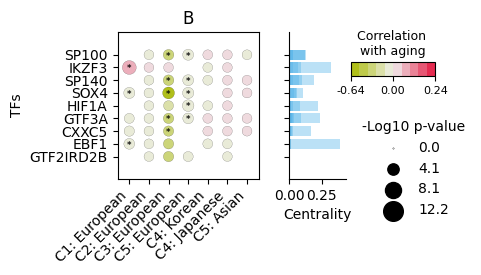

In [93]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

cell_type = 'B'
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=None, 
                            feature_type='tf_activity', sizes=(50, 100), min_degree=4, filter_meta_significant=True)

## Interaction of sig TFs

In [2]:
cell_type = 'CD8T' #  Tcm_Naive_CD8 Tem_Temra_CD8
type = 'bulk'
race = 'asian'
min_degree_consensus = 3

In [3]:
from ciim.src.tf_activity.helper import determine_consensus_nets
consensus_nets = determine_consensus_nets(datasets_e, cell_types, min_degree=min_degree_consensus)
stats_sig = retrieve_sig_stats(type, race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])

In [4]:
def overlap_with_collectri(net):
    collectri = pd.read_csv(f'/vol/projects/jnourisa/prior/collectri.csv')
    net['in_collectri']= False
    net.loc[net['source'].isin(collectri['source']), 'in_collectri'] = True
    print(f'network size: {len(net)}, collectri size: {len(collectri)}, in collectri: {net["in_collectri"].sum()}/{len(net)}') 
    
net = consensus_nets[mapping_minor_2_major.get(cell_type, cell_type)]
overlap_with_collectri(net)

# - filter the net to include on sig tfs add the stats
stats = stats_sig[stats_sig['cell_type']==cell_type]
sig_tfs = stats['tf'].unique()
net = net[(net['source'].isin(sig_tfs)) & (net['target'].isin(sig_tfs))]
net_plus = net.merge(stats, left_on='source', right_on='tf', how='left', suffixes=('', '_'))[['cell_type', 'source' , 'target', 'weight', 'meta_p_adj', 'trend']].drop_duplicates(subset=['source', 'target', 'meta_p_adj'])
net_plus = net_plus.merge(stats, left_on='target', right_on='tf', how='left', suffixes=('', '_target'))[['cell_type', 'source' , 'target', 'weight', 'meta_p_adj', 'trend', 'meta_p_adj_target', 'trend_target']].drop_duplicates(subset=['source', 'target'])
overlap_with_collectri(net_plus)
net_plus.to_csv(f'../output/nets/net_sig_onlyTFs_{cell_type}.csv', index=False)

network size: 3502, collectri size: 43178, in collectri: 3290/3502
network size: 119, collectri size: 43178, in collectri: 118/119


In [89]:
if False:
    # Create out-degree and in-degree DataFrames
    out_degree = net.groupby('source').size().reset_index(name='out_degree')
    in_degree = net.groupby('target').size().reset_index(name='in_degree')

    # Merge and fill missing values
    df_combined = pd.merge(out_degree, in_degree, left_on='source', right_on='target', how='outer').fillna(0)

    # Standardize column names
    df_combined['TF'] = df_combined['source'].combine_first(df_combined['target'])
    df_combined = df_combined[['TF', 'out_degree', 'in_degree']]

    sns.scatterplot(data=df_combined, x='out_degree', y='in_degree')

In [5]:
'RORA' in net['source'].unique()

True

In [7]:
import plotly.express as px
import pandas as pd

# Create out-degree and in-degree DataFrames
out_degree = net.groupby('source').size().reset_index(name='out_degree')
in_degree = net.groupby('target').size().reset_index(name='in_degree')

# Merge and fill missing values
df_combined = pd.merge(out_degree, in_degree, left_on='source', right_on='target', how='outer')

# Standardize column names
df_combined['TF'] = df_combined['source'].combine_first(df_combined['target'])
# df_combined = df_combined[['TF', 'out_degree', 'in_degree']]

# Plot with Plotly
fig = px.scatter(
    df_combined,
    x='out_degree',
    y='in_degree',
    text='TF',
    labels={'out_degree': 'Out-degree', 'in_degree': 'In-degree'},
    title=f'{cell_type}-{race}',
    template='simple_white'
)
fig.update_traces(marker=dict(size=10, opacity=0.7),
                  textposition='top center')
fig.update_layout(height=400, width=400)
fig.show()

## Stats

In [79]:
if True:
    race='european'

    stats = retrieve_sig_stats(type='bulk', race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
else:
    race = 'Common'
    stats = retrieve_valid_stats(type)

In [81]:
# stats[stats['cell_type']=='MONO']

Text(0.5, 1.0, 'Significant TFs (european)')

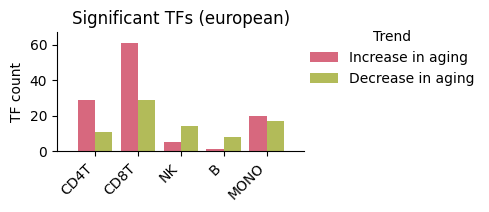

In [82]:
from ciim.src.tf_activity.plots import plot_sig_tfs_stats
    # plt.savefig(f'../output/tf_activation/trends.png', dpi=300)
stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
plot_sig_tfs_stats(stats, figsize=(5, 2))
plt.title(f'Significant TFs ({race})')

## Identify sig networks

In [94]:
from ciim.src.tf_activity.helper import retrieve_valid_stats
retrieve_valid_stats(type) 

,tf,cell_type,trend
0,ARID5B,CD4T,Increase in aging
2,BATF,CD4T,Increase in aging
4,BCL11B,CD4T,Decrease in aging
6,BHLHE40,CD4T,Increase in aging
8,ELK3,CD4T,Increase in aging
...,...,...,...
214,PLSCR1,NK,Decrease in aging
216,PRDM1,NK,Increase in aging
218,REL,NK,Decrease in aging
220,SATB1,NK,Decrease in aging


In [95]:
from ciim.src.tf_activity.helper import wrapper_extract_sig_network
type = 'bulk'

par = {
    'type': type,    
    'min_degree_network': 5,
    'sig_nets': f'../output/tf_activation/sig_nets_{type}.csv'
}
if True:
    wrapper_extract_sig_network(par)

FileNotFoundError: [Errno 2] No such file or directory: '../output/tf_activation/stats_targets_bulk.csv'

## Network topology

In [16]:
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

nets = pd.read_csv(f'../output/tf_activation/sig_nets_{type}.csv')

In [68]:
# nets['cell_type'].unique()

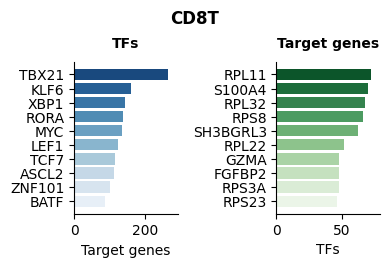

In [17]:
from ciim.src.tf_activity.plots import plot_net_degrees

for cell_type in ['CD8T']:
    net = nets[nets['cell_type'] == cell_type]
    plot_net_degrees(net)
    plt.suptitle(f'{cell_type}', fontsize=12, y=1.05, fontweight='bold')
    

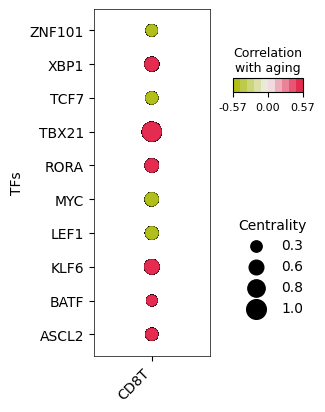

In [18]:
if True:
    from ciim.src.common import cmap_trend
    col = 'source'

    top_tf_n = 10
    top_tfs_df = []

    for cell_type in nets['cell_type'].unique():
        net = nets[nets['cell_type'] == cell_type]
        # Calculate raw out-degree
        out_deg = net.groupby(col).size().reset_index(name='degree')
        out_deg = out_deg.sort_values('degree', ascending=False).head(top_tf_n)

        # Normalize out-degree
        out_deg['degree'] = out_deg['degree'] / out_deg['degree'].max()

        out_deg['cell_type'] = cell_type
        out_deg = out_deg.merge(net[['cell_type', col]], on=['cell_type', col], how='left')

        top_tfs_df.append(out_deg)

    # Combine
    top_tfs_df = pd.concat(top_tfs_df)
    top_tfs_df = top_tfs_df.merge(stats_valid[['cell_type', 'tf', 'slope']], left_on=['cell_type', 'source'], right_on=['cell_type', 'tf'], how='left')
    top_tfs_df = top_tfs_df.rename(columns={col: 'target', 'degree': 'centrality'})
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4.5))
    
    dotplot(
        top_tfs_df,
        ax=ax,
        color_col='slope',
        size_col='centrality',
        y='target',
        color_legend_title='Correlation\nwith aging',
        size_legend_title='Centrality',
        palette=cmap_trend,
        sizes=(20, 200),
        size_legend_loc=(1.2, .1),
        color_legend_loc=(1, .7),
        linewidth=0.1,
        size_legend_scale=200,
        alpha=0.8,
    )
    ax.set_ylabel('TFs')
    ax.margins(x=0.3, y=0.07)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)  # Set the border thickness to 0.5


## Shared sig TFs between cell types

In [121]:
stats_sig = retrieve_sig_stats(type, race='european')

['CD8T', 'CD4T', 'MONO', 'NK']


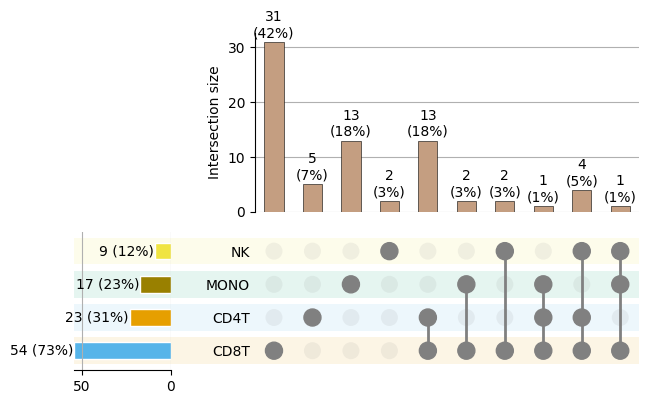

In [122]:
sys.path.append('../../')
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=1, color_map=palette_cell_types)
# plt.savefig(f'../output/tf_activation/interactions.png', dpi=300)
# plt.title('', pad=40)

In [123]:
from ciim.src.common import cmap_trend

from ciim.src.utils.plots import dotplot

df = interaction_main_df.copy()
# if type == 'sc':
#     shared_cell_types = ['CD8T', 'NK']
# else:
#     shared_cell_types = ['CD4T', 'CD8T', 'NK', 'MONO']
# df = df[shared_cell_types]

degree3_tfs = df[df.sum(axis=1)==3].index
print(degree3_tfs)
selected_tfs = degree3_tfs

Index(['CEBPB', 'BATF', 'TCF7', 'DRAP1', 'PRDM1', 'GATA3'], dtype='object')


In [138]:
# stats_all = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')
# stats_all = stats_all[stats_all['tf'].isin(selected_tfs)]
# stats_all = stats_all[stats_all['trend'] != 'Inconsistent'].drop('trend', axis=1)



stats_tfs_mean = stats_sig[['cell_type', 'tf', 'slope', 'meta_p_adj', 'trend']].groupby(['cell_type', 'tf'], as_index=False).mean(numeric_only=True)
stats_tfs_mean = stats_tfs_mean[stats_tfs_mean['tf'].isin(selected_tfs)]

Text(0.5, 1.1, 'Common sig. TFs ')

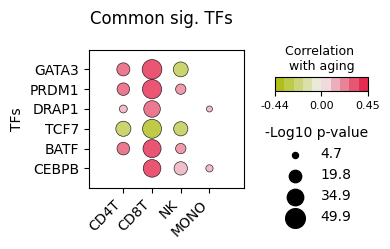

In [143]:
fig, ax = plt.subplots(1, 1, figsize=(2, len(selected_tfs)*.3), 
                        #  gridspec_kw={'width_ratios': [.2, .2]}, 
                         sharey=True)# - plot TF activation stats
df = stats_tfs_mean
df['tf'] = pd.Categorical(df['tf'], categories=selected_tfs, ordered=True)
df = df.sort_values('tf')
df['cell_type'] = df['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO'], ordered=True))
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])
df['slope'] = df['slope'].astype(float)


dotplot(df, ax, 
        color_col='slope', 
        size_col='neg_log10_adj_pval', 
        # palette=palette_trend_2, 
        palette=cmap_trend, 
        show_color_legend=True, 
        show_size_legend=True,
        alpha=.8,
        size_legend_title='-Log10 p-value',
        color_legend_title='Correlation \nwith aging',
        size_legend_loc=(1.1, -.3),
        color_legend_loc=(1.05, 0.6),
        cbar_height='10%',
        size_legend_scale = 200/max(df['neg_log10_adj_pval'])
        )
ax.margins(x=0.4, y=0.2)
ax.set_ylabel('TFs')
# plt.savefig(f'../output/tf_activation/degree3_tfs.png', dpi=300)
plt.suptitle('Common sig. TFs ', fontsize=12, y=1.1)

## Shared sig TFs between CD8T and CD4T

(13,)


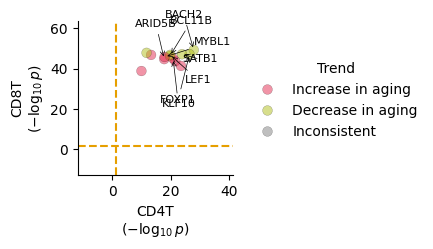

In [157]:
from ciim.src.tf_activity.plots import plot_joint_scatter

interaction_main_ts_df = interaction_main_df[['CD4T', 'CD8T']]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
sig_tfs_ts = np.setdiff1d(sig_tfs_ts, degree3_tfs)
print(sig_tfs_ts.shape)
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(sig_tfs_ts)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.5, y=0.3)

## GSEA

In [11]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
type = 'bulk'

stats_sig = retrieve_sig_stats(type, race='european')
pathway_scores = pathway_analysis_wrapper(stats_sig)
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["Adjusted P-value"])

cell_type: CD4T, trend: Increase in aging, n tfs: 29
(5, 10)
cell_type: CD4T, trend: Decrease in aging, n tfs: 12
(6, 10)
cell_type: CD8T, trend: Increase in aging, n tfs: 58
(6, 10)
cell_type: CD8T, trend: Decrease in aging, n tfs: 25
(2, 10)
cell_type: NK, trend: Increase in aging, n tfs: 5
(6, 10)
cell_type: NK, trend: Decrease in aging, n tfs: 11
(7, 10)
cell_type: B, trend: Increase in aging, n tfs: 1
(0, 10)
cell_type: B, trend: Decrease in aging, n tfs: 5
(5, 10)
cell_type: MONO, trend: Increase in aging, n tfs: 20
(6, 10)
cell_type: MONO, trend: Decrease in aging, n tfs: 13
(5, 10)


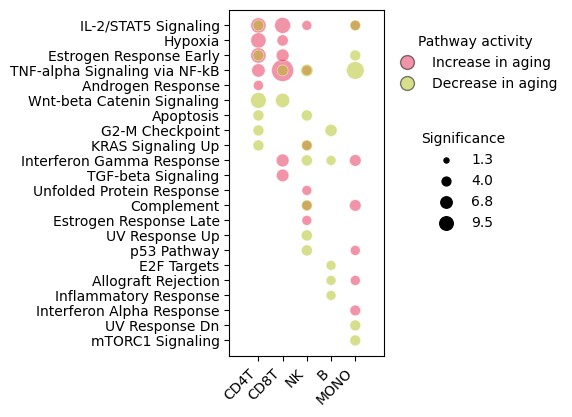

In [37]:
from ciim.src.tf_activity.plots import dotplot_category_color
    
fig, ax = plt.subplots(1, 1, figsize=(2, 4.5))
pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
dotplot_category_color(pathway_scores, 
            ax, 
            color_col='trend', 
            size_col='neg_log10_adj_pval', 
            x='cell_type', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=True, 
            show_size_legend=True,
            size_legend_title='Significance',
            color_legend_title='Pathway activity',
            size_legend_loc=(1.2, 0.35),
            color_legend_loc=(1.02, 0.75),
            y_label='',
            alpha=0.5)

In [33]:
pathway_scores['Term'].unique()

array(['IL-2/STAT5 Signaling', 'Hypoxia', 'Estrogen Response Early',
       'TNF-alpha Signaling via NF-kB', 'Androgen Response',
       'Wnt-beta Catenin Signaling', 'Apoptosis', 'G2-M Checkpoint',
       'KRAS Signaling Up', 'Interferon Gamma Response',
       'TGF-beta Signaling', 'Unfolded Protein Response', 'Complement',
       'Estrogen Response Late', 'UV Response Up', 'p53 Pathway',
       'E2F Targets', 'Allograft Rejection', 'Inflammatory Response',
       'Interferon Alpha Response', 'UV Response Dn', 'mTORC1 Signaling'],
      dtype=object)

                                           Genes
trend                                           
Decrease in aging                     BCL11B;MYC
Increase in aging  KLF10;ELF1;BHLHE40;RARA;MYBL1


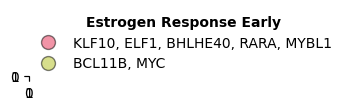

In [40]:
# - the term with bifurcation enrichment
term = 'Estrogen Response Early'
cell_type = 'CD4T'

def explode_bifurcation_term(cell_type, term):
    pathway_scores_t = pathway_scores[(pathway_scores['Term'] == term) & (pathway_scores['cell_type'] == cell_type)]
    df = pathway_scores_t.groupby(['trend'])['Genes'].apply(lambda x: ', '.join(x)).reset_index(name='Genes').set_index('trend')
    print(df)
    increased_tfs = df.loc['Increase in aging', :].values

    decreased_tfs = df.loc['Decrease in aging', :].values

    ';'.join(increased_tfs[0].split(';'))  # original

    evey_n_words = 5
    pp_nfkb_cd8t = {'Increase in aging': ', \n'.join([
                        ', '.join(increased_tfs[0].split(';')[i:i+evey_n_words])
                        for i in range(0, len(increased_tfs[0].split(';')), evey_n_words)
                        ]), 
                    'Decrease in aging': ', '.join(decreased_tfs[0].split(';'))}
                
    # - actual plot
    palette = palette_trend_2
    from matplotlib.lines import Line2D
    alpha = .5

    plt.figure(figsize=(0, 0))
    color_legend = [
            Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
                markersize=10, label=pp_nfkb_cd8t[name], alpha=alpha) 
            for name, color in palette.items()
        ]
    color_legend_handle = plt.legend(
        title=term,
        title_fontsize=10,
        fontsize=10,
        handles=color_legend, 
        loc=(1, .1), 
        frameon=False
    )

    # Set bold font weight for legend title manually
    color_legend_handle.get_title().set_fontweight('bold')
explode_bifurcation_term(cell_type, term)


# Minor cell types

## Heatmap

In [41]:
from ciim.src.common import mapping_minor_2_major
# - get the stats for bulk of both gender
stats_store = []
for type in ['bulk', 'bulk_minor']:
    stats_tf = pd.read_csv(f'../output/tf_activation/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, race='european').drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    stats_tf['major_cell_type'] = stats_tf['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['major_cell_type', 'cell_type', 'tf', 'slope', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf'])

# - plot
stats_all_combined['major_cell_type'] = stats_all_combined['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))


In [42]:
ordered_cell_names = ['CD4T',
                    'Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'CD8T',
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',

                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'B',
                    'Memory_B',
                    'Naive_B',
                    ]
stats_all_combined['cell_type'] = pd.Categorical(stats_all_combined['cell_type'], categories=ordered_cell_names, ordered=True)

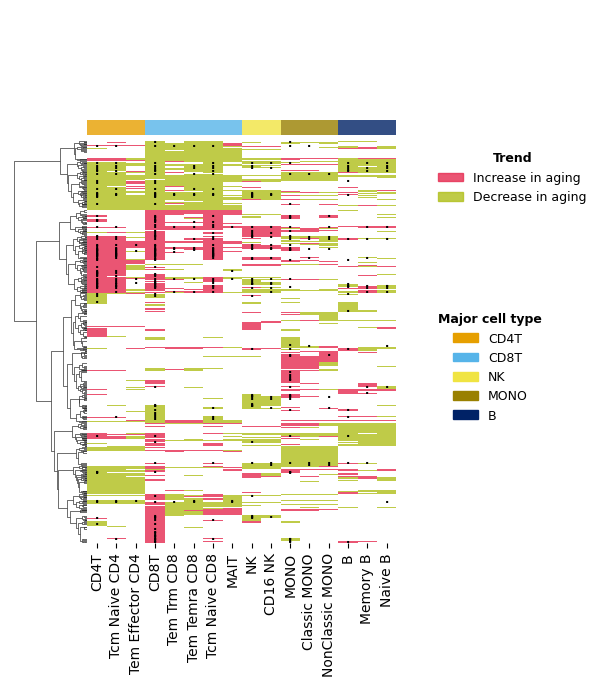

In [43]:
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
heamap_plot_minor_cell_types(stats_all_combined, palette=palette_cell_types, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})

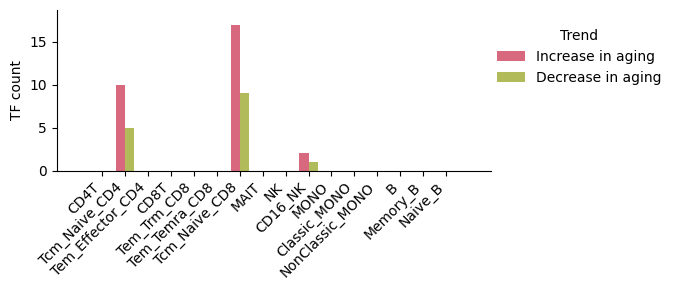

In [49]:
# stats_valid = retrieve_sig_stats(type='bulk_minor', analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
stats_valid = retrieve_valid_stats(type='bulk_minor').drop_duplicates(subset=['cell_type', 'tf'])

stats_valid['cell_type'] = pd.Categorical(stats_valid['cell_type'], categories=ordered_cell_names, ordered=True)
plot_sig_tfs_stats(stats_valid, figsize=(7, 3))

### Cell type proportions

In [91]:
obs_dict = {dataset:ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets}

In [92]:
type = 'bulk_minor'
stats_minor = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')
stats_minor_sig = retrieve_valid_stats(type)
stats_minor_sig.head()

,tf,p_value,slope,dataset,cell_type,age_group,condition,slope_disease,values_case,values_control,adj_p_value,meta_p,meta_p_adj,neg_log10_adj_pval,trend,analysis,p_value_adj
11556,ANXA1,5.466096e-11,0.359625,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,5.466096e-11,1.610001e-09,8.793174,Increase in aging,validation,NaN
11558,ARID5B,7.798596e-06,0.249681,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,7.798596e-06,2.091442e-05,4.679554,Increase in aging,validation,NaN
11559,BACH2,1.640360e-08,-0.312371,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,1.640360e-08,1.209766e-07,6.917299,Decrease in aging,validation,NaN
11560,BATF,1.756890e-11,0.368155,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,7.580904e-07,3.194810e-06,5.495555,Increase in aging,validation,NaN
11562,BCL11B,3.421349e-04,-0.201148,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,3.421349e-04,6.728652e-04,3.172072,Decrease in aging,validation,NaN


### Low-dimensional plot

In [93]:
# - 
sig_tf_size = stats_minor_sig[['cell_type', 'tf']].groupby('cell_type').size().reset_index(name='sig_tfs').rename({'cell_type': 'Sub_CT'}, axis=1)
sig_tf_size

,Sub_CT,sig_tfs
0,CD16_NK,7
1,Tcm_Naive_CD4,44
2,Tcm_Naive_CD8,50
3,Tem_Trm_CD8,1


In [94]:
if False:
    !mkdir ../output/tf_activation/umap/
    adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/data1_bulk_minor.h5ad')
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    adata.write('../output/tf_activation/umap/data_bulk_minor.h5ad')
else:
    adata = ad.read_h5ad('../output/tf_activation/umap/data_bulk_minor.h5ad')
adata.obs = adata.obs.merge(sig_tf_size, on='Sub_CT', how='left')
adata.obs['sig_tfs'] = adata.obs['sig_tfs'].fillna(0).astype(int)
adata = adata[~adata.obs['Sub_CT'].isna(), :]

In [95]:
# adata.obs['Major_CT'] = adata.obs['Major_CT'].astype(str)
adata.obs['Major_CT'].unique()

['B', 'NK', 'MONO', 'CD8T', 'CD4T']
Categories (5, object): ['B', 'CD4T', 'CD8T', 'MONO', 'NK']

In [ ]:
# - plot the umap of #sig tfs per subtype
from ciim.src.utils.plots import plot_umap

for cell_type in ['CD8T', 'CD4T', 'NK', 'MONO']:
        adata_cell = adata[adata.obs['Major_CT'].isin([cell_type])]
        adata_cell.obs['Sub_CT'] = adata_cell.obs['Sub_CT'].astype(str)
        adata_cell = adata_cell[~adata_cell.obs['Sub_CT'].isna(), :]
        adata_cell = adata_cell[~adata_cell.obs['age'].isna(), :]
        sorted_subtypes = mapping_major_2_minor[cell_type]
        # - sanity check 
        # print([c for c in sorted_subtypes if c not in adata_cell.obs['Sub_CT'].unique()])
        # aaa
        diff = np.setdiff1d(adata_cell.obs['Sub_CT'].unique(), sorted_subtypes)
        if diff.shape[0]>0:
                print(diff)
        # - plot the umap of #sig tfs per subtype  
        
        palette={name: value for name, value in zip(sorted(sorted_subtypes), colors_blind)}
        print(palette)
        fig, ax = plt.subplots(1, 1, figsize=(6, 3))
        # ax = axes[0]
        adata_cell.obs['Sub_CT'] = adata_cell.obs['Sub_CT'].astype(CategoricalDtype(categories=sorted_subtypes, ordered=True))
        print(adata_cell.obs['Sub_CT'].unique())
        plot_umap(adata_cell, color='Sub_CT', ax=ax, s=1, X_label='X_pca', alpha=.9, sort_colors=False,
                bbox_to_anchor=(.9,.1), palette=palette,
                margins=dict(x=.1, y=.1), 
                )  
        ax = axes[1]
        groups = adata_cell.obs['sig_tfs'].unique()
        plot_umap(adata_cell, color='sig_tfs', ax=ax, s=1, X_label='X_pca', alpha=.9, 
                bbox_to_anchor=(.9,.1), 
                margins=dict(x=.1, y=.1), 
                palette={name: value for name, value in zip(sorted(groups), sns.color_palette("viridis", n_colors=len(groups)))},
                legend_title='TFs count',
                )  

        plt.suptitle(f'TFs significantly associated with age ({cell_type})', fontsize=12)
        plt.tight_layout()


AssertionError: Don’t call _normalize_index with non-categorical/string names

# STD

In [58]:
pd.read_csv(f'../output/tf_activation/stats_tfs_sc.csv')

,tf,p_value,slope,dataset,cell_type,age_group,condition,slope_disease,values_case,values_control,adj_p_value
0,ADNP,5.226819e-05,-0.128781,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
1,ANXA1,1.489113e-15,0.250946,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
2,ANXA11,3.954323e-16,0.255876,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
3,APEX1,3.002488e-13,0.230051,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
4,ARID5B,1.822060e-13,0.232105,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10880,ZNF581,9.465691e-02,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[1.52272198 1.10979719 1.02750641 1.27967717 1...,[1.7308587 1.13832118 1.02390717 2.30559863 1...,0.133523
10881,ZNF622,1.142740e-03,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[3.00796087 2.93784677 3.01218627 3.58644526 3...,[3.8156539 2.28822334 2.15113002 4.67379409 1...,0.003312
10882,ZNF706,1.629860e-02,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[15.3652678 14.3707387 16.5267336 14.990143...,[17.17229204 15.04296109 12.59231433 18.655654...,0.027552
10883,ZNF90,2.467785e-02,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[ 8.82919807 16.12991171 13.1865046 13.069082...,[12.01867402 8.93440599 10.33188634 13.275075...,0.040279


In [51]:
# - get the stats for bulk of bulk and sc
stats_store = []
for type in ['bulk', 'sc_std']:
    stats_tf = pd.read_csv(f'../output/tf_activation/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    
    stats_tf['type'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'type', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'type', 'is_significant'])

# - plot
stats_all_combined['type'] = stats_all_combined['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=5, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='type', second_col_palette={'Bulk': 'gray', 'STD': 'lightblue'},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'type': 'Analysis'})

FileNotFoundError: [Errno 2] No such file or directory: '../output/tf_activation/stats_tfs_sc_std.csv'

In [73]:
cell_type = 'CD8T'

stats_valid_store = []
for type in ['bulk', 'sc']:
    stats_valid = retrieve_valid_stats(type)
    stats_valid = stats_valid[stats_valid['cell_type'].isin([cell_type])]

    nets = pd.read_csv(f'../output/tf_activation/sig_nets_{type}.csv')
    nets = nets[nets['cell_type'].isin([cell_type])]
    central_tfs = nets.groupby(['source']).size().sort_values(ascending=False).head(40).index.to_numpy()
    stats_valid = stats_valid[stats_valid['tf'].isin(central_tfs)]
    # stats_valid = stats_valid.sort_values('meta_p_adj', ascending=True).head(30)
    stats_valid['type'] = type
    stats_valid['cell_type'] = cell_type
    stats_valid_store.append(stats_valid)
stats_valid_all = pd.concat(stats_valid_store, axis=0)
stats_valid_all['neg_log10_adj_pval'] = -np.log10(stats_valid_all['meta_p_adj'])
stats_valid_all['type'] = stats_valid_all['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))


In [74]:
df_common = stats_valid_all.groupby(['cell_type', 'tf']).size()
tuple_index = df_common[df_common==2].index
stats_valid_all = stats_valid_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

In [54]:
'GATA3' in stats_valid_all['tf'].unique()

False

In [79]:
stats_valid_all['tf'].unique()

array(['RPL35', 'RPL6', 'RPS10', 'RPS4X', 'SATB1', 'TBX21', 'TCF7',
       'TPI1', 'UBB', 'UQCRB', 'XBP1', 'YWHAZ', 'ZBTB38', 'ZEB2',
       'ZNF101', 'ZNF600'], dtype=object)

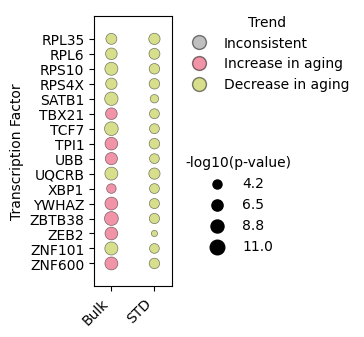

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(1, 3.5))
dotplot(stats_valid_all, ax=ax,
        x='type', y='tf', color_col='trend', size_col='neg_log10_adj_pval', 
        palette=palette_trend, sizes=(20, 100), alpha=.5)
ax.margins(x=0.4, y=0.1)

In [ ]:
read_tf_acts

# Gender


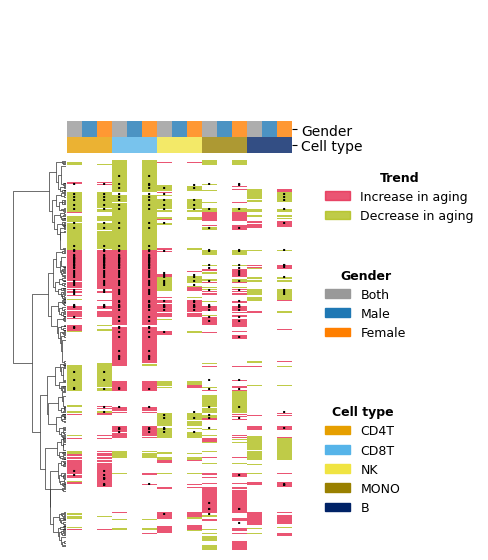

In [21]:
# - get the stats for bulk of both gender
stats_store = []
for type in ['bulk', 'bulk_M', 'bulk_F']:
    stats_tf = pd.read_csv(f'../output/tf_activation/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    
    stats_tf['gender'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'gender', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'gender', 'is_significant'])

# - plot
stats_all_combined['gender'] = stats_all_combined['gender'].map({'bulk': 'Both', 'bulk_F': 'Female', 'bulk_M': 'Male'}).astype(CategoricalDtype(categories=['Both', 'Male', 'Female'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=5, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='gender', second_col_palette={**{'Both': 'gray', **palette_genders}},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'gender': 'Gender'})

# Trajectory plot: TF acitvity with age


In [ ]:

from ciim.src.tf_activity.plots import plot_trends
from ciim.src.common import palette_datasets
if True:
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: adata_lambda(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.tight_layout()
    plt.savefig(f'../output/tf_activation/trends_{cell_type}_case.png', dpi=300)

## TF activity trend vs expression trend in aging


In [ ]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from ciim.src.tf_activity.helper import determine_stats, adata_lambda

stats_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()
from src.tf_activity.plots import plot_activation_vs_expression
df = stats_all_sig_combined.copy()
df = df[df['cell_type']=='CD8T']
plot_activation_vs_expression(df, y_label='Activation significance', x_label='Expression significance')
plt.suptitle("TF activation vs expression (CD8T)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/activation_vs_expression.png', dpi=300)